In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Task A

In [2]:
L = 6 #length of the chain
V = -1
t_start = 0
t_end = 20
#h_bar = 1.05457182e-34
h_bar = 1
epsilon1 = 2
c0 = [1,0,0,0,0,0]
t=np.linspace(t_start,t_end,1000)
H1 = np.array([
    [epsilon1, V,  0,  0,  0,  0],
    [V,  0, V,  0,  0,  0],
    [0,  V,  0, V,  0,  0],
    [0,  0, V,  0, V,  0],
    [0,  0,  0, V, 0, V],
    [0,  0,  0,  0, V, 0]
])

E_lambda, eigenvectors = np.linalg.eigh(H1)



def cn_lambdat(t,m):
 def cm():
    k = []

    for lam in range(L):
        b = np.vdot(eigenvectors[:, lam], c0)
        k.append(b)

    return k
 
 y = []
 for i in range(len(t)):    
     a = np.exp((-1j*E_lambda*t[i])/h_bar) *eigenvectors[m-1, :] *cm()
     y.append(np.sum(a))
     
 return  np.abs(np.array(y))**2

#print(eigenvectors[:,0])


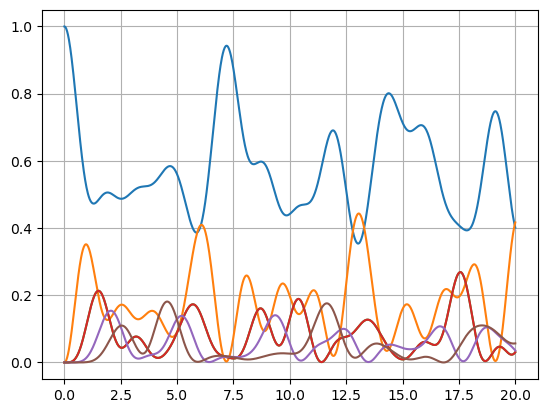

In [3]:
fig, ax = plt.subplots()
 
plt.plot(t,cn_lambdat(t,1))
plt.plot(t,cn_lambdat(t,2))
plt.plot(t,cn_lambdat(t,3))
plt.plot(t,cn_lambdat(t,3))
plt.plot(t,cn_lambdat(t,4))
plt.plot(t,cn_lambdat(t,5))
plt.grid()

# Task B

In [4]:
# Define values
L = 6
U_1 = 0
U_n = 15
V = -1
eps_1 = -15
eps_n = 0


In [5]:
def H(Delta):
    H = np.zeros((L**2, L**2))
    # TODO: diagonal elements
    H += np.diag(np.ones(L**2-1) * V, 1) # add the V elements directly offset from the diagonal
    H += np.diag(np.ones(L**2-1) * V, -1) # " "
    H[L * np.arange(1, L), L * np.arange(1, L) - 1] = 0 # get rid of the ones that aren't actually next to each other
    H[L * np.arange(1, L) - 1, L * np.arange(1, L)] = 0 # " "
    H += np.diag(np.ones(L**2-L) * V, L) # add the V elements far offset from the diagonal
    H += np.diag(np.ones(L**2-L) * V, -L) # " "
    #np.set_printoptions(threshold=np.inf)
    H[0][0] = 2*(-15+Delta)
    H[1][1] = -15+Delta
    H[2][2] = -15+Delta
    H[3][3] = -15+Delta
    H[4,4] = -15 + Delta
    H[5,5] = -15 + Delta
    H[7,7] = U_n
    H[14,14] = U_n
    H[21,21] = U_n
    H[28,28] = U_n
    H[35,35] = U_n
    return H

In [6]:
H(5)

array([[-20.,  -1.,   0., ...,   0.,   0.,   0.],
       [ -1., -10.,  -1., ...,   0.,   0.,   0.],
       [  0.,  -1., -10., ...,   0.,   0.,   0.],
       ...,
       [  0.,   0.,   0., ...,   0.,  -1.,   0.],
       [  0.,   0.,   0., ...,  -1.,   0.,  -1.],
       [  0.,   0.,   0., ...,   0.,  -1.,  15.]], shape=(36, 36))

In [12]:
#Implementation of the Eq27 for two particles:
#eigenvalues , eigenvectors = np.linalg.eigh(H) #eigenvalues are the energy values and the eigenvectors contain the expansion coefficents
#print(eigenvectors_rearranged)
c0 = np.array([1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0])
#print(np.shape(c0))




def cm(t,d):
    eigenvalues , eigenvectors = np.linalg.eigh(H(d))

    k = []

    for l in range(36):
        b = np.vdot(eigenvectors[:, l], c0)
        k.append(b)
        #print(k)

    return k


def cn_lambdat2(t,n,m,d): #t is the time, n is the index for the basis vector(basis function) in the Hilbertspace(L²) that contains particle 1 and m is the index of the basis vector that contains particle 2
 eigenvalues , eigenvectors = np.linalg.eigh(H(d))
 
 y = []
 for i in range(len(t)):    
     a = np.exp((-1j*eigenvalues*t[i])/h_bar) *eigenvectors[(n-1)*6 + (m-1), :] *cm(t[i],d)
     y.append(np.sum(a))
     
 return  np.abs(np.array(y))**2

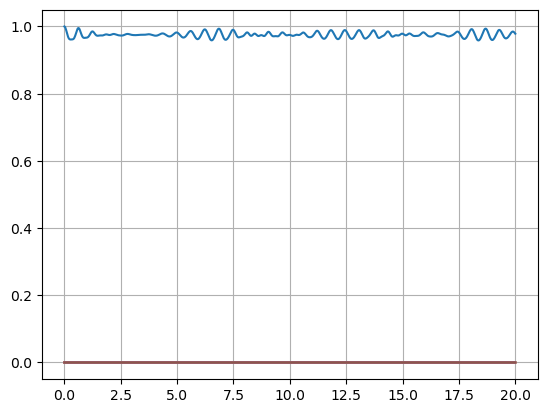

In [13]:
fig, ax = plt.subplots()
for n in range(L):
    plt.plot(t,cn_lambdat2(t,n+1,n+1,5))

plt.grid()

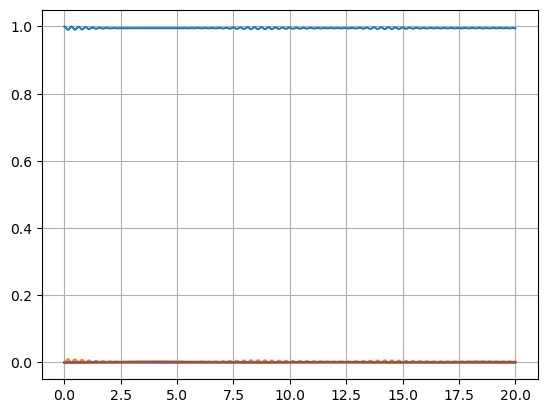

In [14]:
for n in range(L):
    p_up = np.zeros(1000)   
    for m in range(L):
        p_up += cn_lambdat2(t,n+1,m+1,5)
    plt.plot(t,p_up)       
plt.grid()

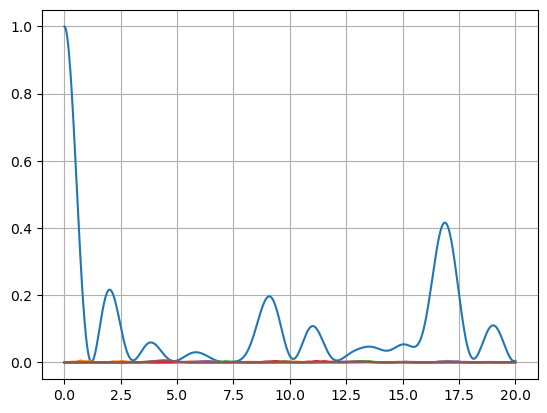

In [10]:
fig, ax = plt.subplots()
for n in range(L):
    plt.plot(t,cn_lambdat2(t,n+1,n+1,15))

plt.grid()

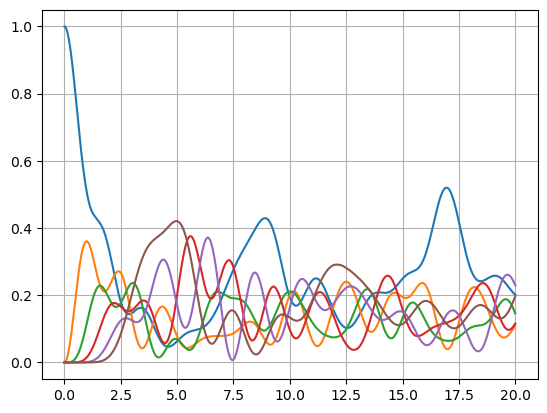

In [11]:
for n in range(L):
    p_up = np.zeros(1000)   
    for m in range(L):
        p_up += cn_lambdat2(t,n+1,m+1,15)
    plt.plot(t,p_up)       
plt.grid()